# Processing ERA5 data for Scale Analysis 

**Purpose**: Code for producing ERA5 data for scale analysis. I will be processing data output for (u,v) velocity at 10 meters.

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
from xmitgcm import open_mdsdataset
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cmocean.cm as cmo

#--- Other Functions ---# 
sys.path.append("/home/lcolosi/AirSeaCoupling/tools/")
import cartopy_figs as cart

Set data analysis parameters

In [3]:
# Set model extration parameters  
year = 2017
VAR_NAME = "v10m" 

# Path to the binary input file
INPUT_FILE = "/project_shared/ERA5/ERA5_" + VAR_NAME + "_2015"  

# Grid configuration
NX = 1280                  # number of longitudes
DX = 360.0 / NX            # lon spacing in degrees (0.28125°)

# Data type of binary file:
# '>f4' = big-endian float32 (same as MATLAB fread with 'single','b')
DTYPE = ">f4"

# Region of interest (latitude, longitude bounds)
# Longitude uses 0–360° convention
LAT_MIN = 32.5
LAT_MAX = 35
LON_MIN = 236.0
LON_MAX = 241.0

# Output folder and filename for the regional subset
OUTPUT_DIR = "/data/SO3/lcolosi/era5/CCS/"
OUTPUT_FILE = "ERA5_" + VAR_NAME + "_CCS_region_" + str(year) + ".nc"

Build latitude grid 

In [4]:
# Starting latitude (south pole)
y0 = -89.7848850

# Manually set the spacing between latitudes in four regions: 

#--- South Pole ---# 
first15 = np.array([
    0.2786766, 0.2803199, 0.2806917, 0.2808328, 0.2809011,
    0.2809392, 0.2809626, 0.2809781, 0.2809888, 0.2809965,
    0.2810023, 0.2810067, 0.2810102, 0.2810129, 0.2810151
])

#--- North Pole ---# 
last15 = np.array([
    0.2810151, 0.2810129, 0.2810102, 0.2810067, 0.2810023,
    0.2809965, 0.2809888, 0.2809781, 0.2809626, 0.2809392,
    0.2809011, 0.2808328, 0.2806917, 0.2803199, 0.2786766
])

#--- Near-polar region ---# 
mid33  = np.ones(33)  * 0.2810258

#--- Mid-latitudes (tropics and extra-tropics) ---# 
mid543 = np.ones(543) * 0.2810302

# Set the spacing between latitudes (length = 639)
dy = np.concatenate([first15, # South Pole (fine grid)
                     mid33,   # Near South Pole
                     mid543,  # Equator (coarse grid)
                     mid33,   # Near North Pole
                     last15]) # North Pole (fine grid)

# Number of latitude points = length(dy) + 1
NY = dy.size + 1

# Generating the latitude coordinate 
y = np.empty(NY)
y[0] = y0
y[1:] = y0 + np.cumsum(dy)

# Print summary 
print("Latitude grid size:", y.size)
print("Min/Max latitude:", y.min(), y.max())

Latitude grid size: 640
Min/Max latitude: -89.784885 89.784885400002


Build longitude grid 

In [5]:
x = np.arange(NX) * DX

# Print summary 
print("Longitude grid size:", x.size)
print("Min/Max longitude:", x.min(), x.max())

Longitude grid size: 1280
Min/Max longitude: 0.0 359.71875


Read in binary file and reshape to (time, lat, lon) grid 

In [6]:
# Read binary file as a flat 1D array
flat = np.fromfile(INPUT_FILE, dtype=DTYPE)

# Check that file size is an integer multiple of a full grid
if flat.size % (NX * NY) != 0:
    raise ValueError(
        f"File size {flat.size} is not divisible by nx*ny ({NX*NY}). "
        "Check DTYPE or grid dimensions."
    )

# Number of time steps
NT = flat.size // (NX * NY)
print(f"Detected nt = {NT} time steps")

# Reshape flat array → (nt, ny, nx)
data = flat.reshape((NT, NY, NX))

Detected nt = 8760 time steps


Slice the array into a subset region off of california

In [7]:
# Boolean masks for lat/lon indices we want
lat_mask = (y >= LAT_MIN) & (y <= LAT_MAX)
lon_mask = (x >= LON_MIN) & (x <= LON_MAX)

# Apply masks: first restrict latitude, then longitude
data_reg = data[:, lat_mask, :][:, :, lon_mask]
lat_reg  = y[lat_mask] 
lon_reg  = x[lon_mask]

Quick visualization 

/home/lcolosi/miniconda3/envs/ccs_scale/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1646: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


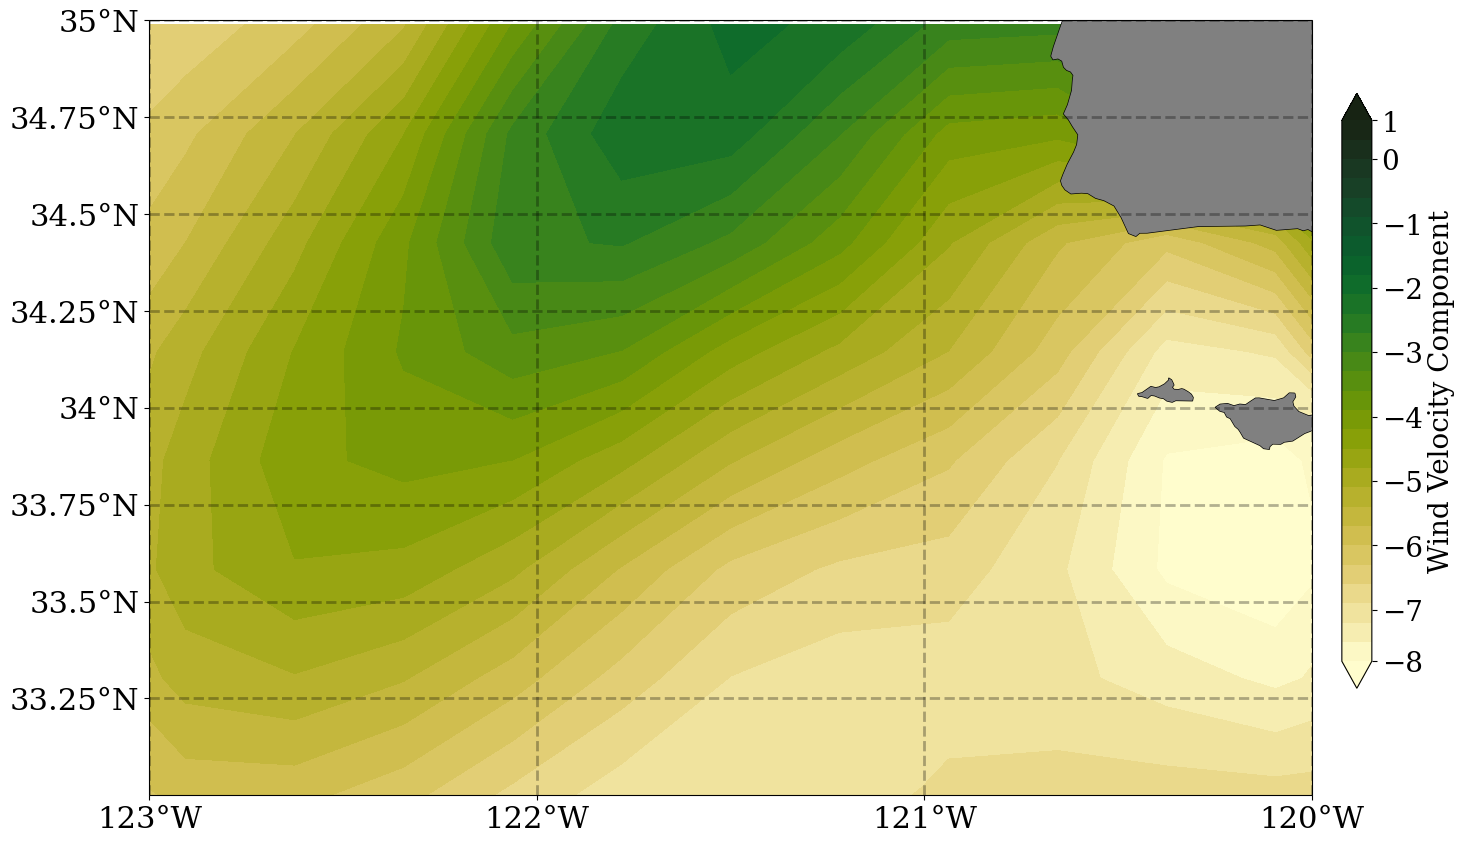

In [8]:
# Set plotting parameters
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123
lon_max = -120
lat_min = 33
lat_max = 35
fontsize = 14

# Set font and fontize 
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": False,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

# Create figure
fig, axes = plt.subplots(1,1, figsize=(15, 17), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot temporal decorrelation scale
mesh = axes.contourf(
    lon_reg, lat_reg, data_reg[0,:,:], levels=30,
    transform=ccrs.PlateCarree(),
    cmap=cmo.speed,  
    shading="auto", 
    extend = 'both'
)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cart.set_cbar(
    mesh,
    cax,
    fig,
    orientation="vertical",
    extend="both",
    cbar_label=r'Wind Velocity Component',
    nbins=10,
    fontsize=20,
    cbar_ticks=[],
    task="regular",
)

# Show the plot
plt.show()

Save data to a netCDf file

In [9]:
# Create output directory if it does not exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Full path to output file
out_path = os.path.join(OUTPUT_DIR, OUTPUT_FILE)

# Build a time coordinate in numpy datetime (assumes data is hourly!!!)
time_pd = pd.date_range(start= str(year) + "-01-01", periods=NT, freq="1h")
time = time_pd.to_numpy()

# Build xarray Dataset from numpy arrays
ds = xr.Dataset(
    {
        VAR_NAME: (("time", "lat", "lon"), data_reg)
    },
    coords={
        "time": time,
        "lat": lat_reg,
        "lon": lon_reg,
    }
)

# --------------------------------------------------------------------
# Add variable metadata
# --------------------------------------------------------------------
if VAR_NAME == "u10m": 
    ds[VAR_NAME].attrs["long_name"] = "10 metre eastward wind component"
    ds[VAR_NAME].attrs["standard_name"] = "eastward_wind"
    ds[VAR_NAME].attrs["units"] = "m s-1"
    ds[VAR_NAME].attrs["description"] = "ERA5 10-meter zonal wind component."
elif VAR_NAME == "v10m": 
    ds[VAR_NAME].attrs["long_name"] = "10 metre northward wind component"
    ds[VAR_NAME].attrs["standard_name"] = "northward_wind"
    ds[VAR_NAME].attrs["units"] = "m s-1"
    ds[VAR_NAME].attrs["description"] = "ERA5 10-meter meridional wind component."

# --------------------------------------------------------------------
# Add coordinate metadata
# --------------------------------------------------------------------
ds["lat"].attrs["long_name"] = "latitude"
ds["lat"].attrs["standard_name"] = "latitude"
ds["lat"].attrs["units"] = "degrees_north"
ds["lat"].attrs["bounds"] = str(LAT_MIN) + " to " + str(LAT_MAX)  

ds["lon"].attrs["long_name"] = "longitude"
ds["lon"].attrs["standard_name"] = "longitude"
ds["lon"].attrs["units"] = "degrees_east"
ds["lon"].attrs["bounds"] = str(LON_MIN) + " to " + str(LON_MAX)  

ds["time"].attrs["long_name"] = "time"
ds["time"].attrs["standard_name"] = "time"

# --------------------------------------------------------------------
# Global attributes (highly recommended)
# --------------------------------------------------------------------
if VAR_NAME == "u10m": 
    ds.attrs["summary"] = (
        "This dataset contains a regional subset of ERA5 10-meter zonal wind "
        "component (u10m) extracted from a global binary file and restricted "
        "to the California Current region."
    )
elif VAR_NAME == "v10m": 
    ds.attrs["summary"] = (
        "This dataset contains a regional subset of ERA5 10-meter meridional wind "
        "component (v10m) extracted from a global binary file and restricted "
        "to the California Current region."
    )

ds.attrs["source"] = "ERA5 reanalysis (ECMWF)"
ds.attrs["history"] = f"Subset and converted to NetCDF on {pd.Timestamp.now()}"
ds.attrs["references"] = "https://www.ecmwf.int/en/forecasts/datasets/reanalysis-datasets/era5"
ds.attrs["author"] = "Luke Colosi"
ds.attrs["institution"] = "Scripps Institution of Oceanography, UCSD"
ds.attrs["region"] = "California Current System"
ds.attrs["conventions"] = "CF-1.8"


# Check if file exists, then delete it
if os.path.exists(out_path):
    os.remove(out_path)

# Save to NetCDF format
ds.to_netcdf(out_path)
print("Saved to:", out_path)


Saved to: /data/SO3/lcolosi/era5/CCS/ERA5_v10m_CCS_region_2017.nc
